In [43]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv("heart.csv")

In [45]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [46]:
df.shape

(918, 12)

In [47]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [49]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [50]:
numeric_cols = ['Age','RestingBP', 'Cholesterol', 'FastingBS','MaxHR', 'Oldpeak',
       'HeartDisease']

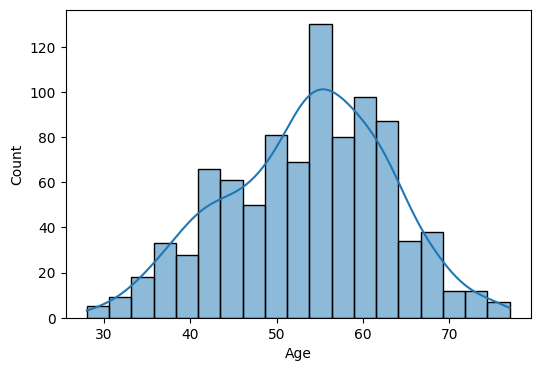

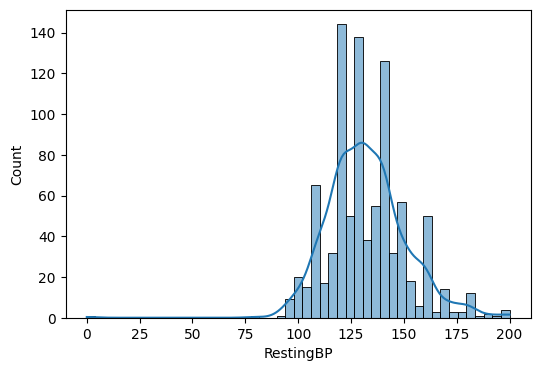

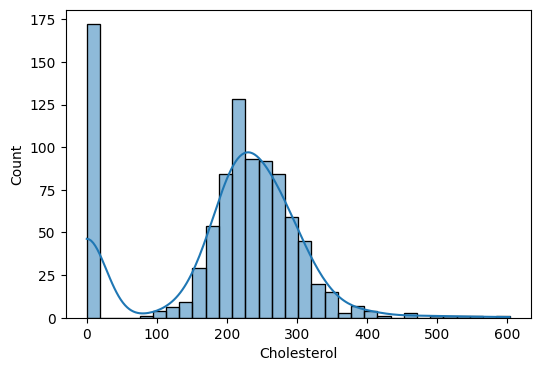

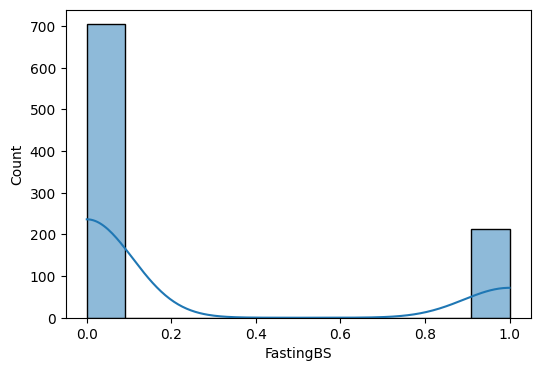

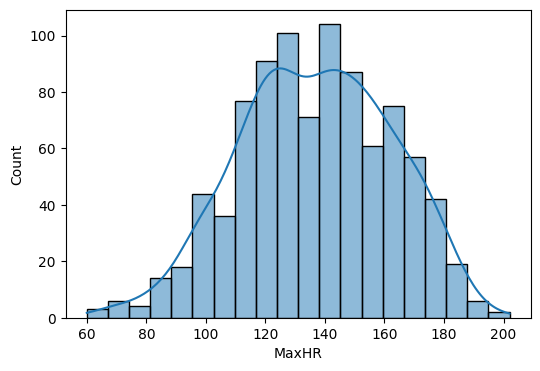

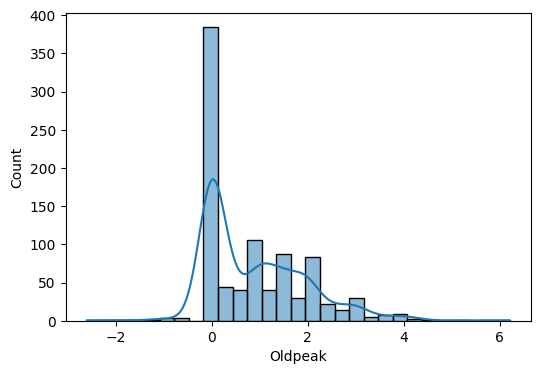

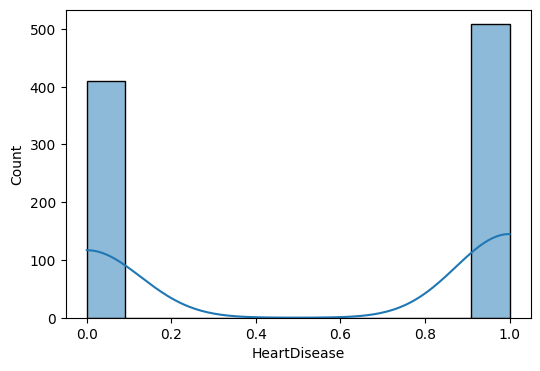

In [51]:
for cols in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True)

In [52]:
(df['Cholesterol']==0).sum()

np.int64(172)

In [53]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [54]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [55]:

df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)


In [56]:
df["Cholesterol"].mean()

np.float64(244.6353887399464)

In [57]:
df["Cholesterol"].fillna(df["Cholesterol"].median(), inplace=True)


In [58]:
df["Cholesterol"] = df["Cholesterol"].round(2)

<Axes: xlabel='Cholesterol', ylabel='Count'>

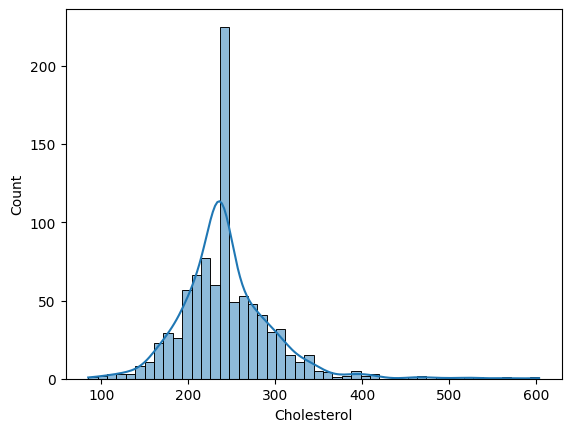

In [59]:
sns.histplot(df["Cholesterol"],kde=True)

In [60]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["RestingBP"].fillna(df["RestingBP"].median(), inplace=True)


In [61]:
df["FastingBS"].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

<Axes: xlabel='Cholesterol'>

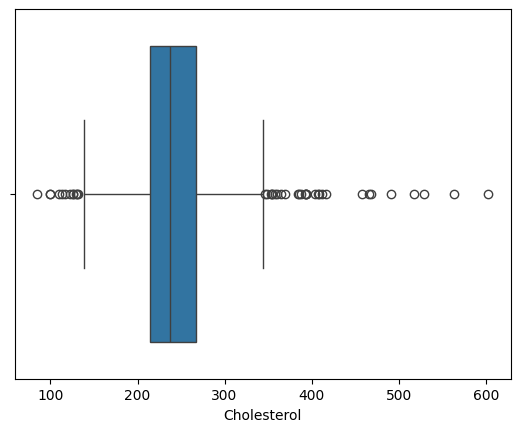

In [62]:
sns.boxplot(x=df["Cholesterol"])

<Axes: >

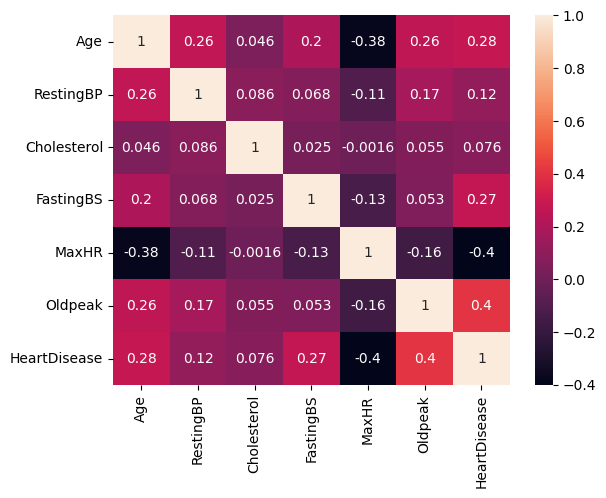

In [63]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [64]:
df_encode = pd.get_dummies(df,drop_first=True)


In [65]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [66]:
bool_cols = [
    "Sex_M",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

df_encode[bool_cols] = df_encode[bool_cols].astype(int)


In [67]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [34]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_encode[cols] = scaler.fit_transform(df_encode[cols])


In [36]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.415002,0.858035,0,1.382928,0.0,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527329,-1.184227,0,0.754157,1.0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141161,0.745617,0,-1.525138,0.0,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303769,-0.547191,0,-1.132156,1.5,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971166,-0.903182,0,-0.581981,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253488,0.389626,0,-0.188999,1.2,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637468,-0.940654,1,0.164684,3.4,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141161,-2.102308,0,-0.857069,1.2,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141161,-0.134991,0,1.461525,0.0,1,0,1,0,0,0,0,0,1,0


In [65]:
from scipy.stats import chi2_contingency
import pandas as pd

# Target variable
target = 'HeartDisease'

# Categorical features (one-hot encoded)
cat_features = [
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

alpha = 0.05
results = []

for feature in cat_features:
    contingency_table = pd.crosstab(df_encode[feature], df_encode[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        'Feature': feature,
        'Chi-Square': chi2,
        'P-Value': p_value,
        'Decision': 'Keep Feature' if p_value < alpha else 'Drop Feature'
    })

chi_square_df = pd.DataFrame(results).sort_values(by='P-Value')
chi_square_df


,Feature,Chi-Square,P-Value,Decision
8,ST_Slope_Up,352.823905,1.028493e-78,Keep Feature
7,ST_Slope_Flat,279.659914,8.906496e-63,Keep Feature
6,ExerciseAngina_Y,222.259383,2.907808e-50,Keep Feature
1,ChestPainType_ATA,146.236323,1.152597e-33,Keep Feature
0,Sex_M,84.145101,4.597617e-20,Keep Feature
2,ChestPainType_NAP,40.608711,1.859758e-10,Keep Feature
5,RestingECG_ST,9.135266,2.507290e-03,Keep Feature
4,RestingECG_Normal,7.327532,6.790624e-03,Keep Feature
3,ChestPainType_TA,2.273802,1.315768e-01,Drop Feature


In [68]:
final_df = df_encode[['Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up']]

In [69]:
final_df

,Sex_M,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,1,1,0,1,0,0,0,1
1,0,0,1,1,0,0,1,0
2,1,1,0,0,1,0,0,1
3,0,0,0,1,0,1,1,0
4,1,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...
913,1,0,0,1,0,0,1,0
914,1,0,0,1,0,0,1,0
915,1,0,0,1,0,1,1,0
916,0,1,0,0,0,0,1,0


In [68]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [70]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [71]:
X = df_encode.drop("HeartDisease",axis=1)
y = df_encode["HeartDisease"]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
scaler = StandardScaler()

In [74]:
X_train_scaled = scaler.fit_transform(X_train)

In [75]:
X_test_scaled = scaler.fit_transform(X_test)

In [76]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "needs_scaling": True
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "needs_scaling": True
    },
    "SVM": {
        "model": SVC(kernel="rbf"),
        "needs_scaling": True
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "needs_scaling": False
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "needs_scaling": False
    }
}


In [77]:
results = {}

for name, config in models.items():
    model = config["model"]
    
    if config["needs_scaling"]:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred)
    }


In [78]:
for model_name, metrics in results.items():
    print("="*60)
    print(f"MODEL: {model_name}")
    print("Accuracy:", metrics["Accuracy"])
    print("F1 Score:", metrics["F1 Score"])
    print("Confusion Matrix:\n", metrics["Confusion Matrix"])
    print("Classification Report:\n", metrics["Classification Report"])


MODEL: Logistic Regression
Accuracy: 0.8641304347826086
F1 Score: 0.8803827751196173
Confusion Matrix:
 [[67 10]
 [15 92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84        77
           1       0.90      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184

MODEL: KNN
Accuracy: 0.8532608695652174
F1 Score: 0.8708133971291866
Confusion Matrix:
 [[66 11]
 [16 91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        77
           1       0.89      0.85      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184

MODEL: SVM
Accuracy: 0.8478260869565217
F1 Score: 0.8679245283018868

In [79]:
best_model_name = "Logistic Regression"
best_model = models[best_model_name]["model"]


In [80]:
import joblib
import os

# create folder if not exists
os.makedirs("saved_models", exist_ok=True)

# save trained logistic regression model
joblib.dump(best_model, "saved_models/logistic_regression_model.pkl")

# save scaler (CRITICAL for LR)
joblib.dump(scaler, "saved_models/standard_scaler.pkl")

# save feature column order
joblib.dump(X.columns.tolist(), "saved_models/columns.pkl")

print("Model, scaler, and feature columns saved successfully.")


Model, scaler, and feature columns saved successfully.
